1.1.1 What are Recommendation Systems?
Recommendation Systems are software tools and algorithms that provide suggestions 
for products, services, or information to users. The suggestions are tailored to the user’s preferences, based on data about their previous behavior and preferences.

The underlying function of a recommendation system can be represented as:

    f : User x Item -> Rating
 
f: represents the predictive function that estimates the utility (or rating) of an item for a particular user.

User: represents the set of all users in the system. Each user is a potential recipient of recommendations.

Item: represents the set of all items available for recommendation. 
These can include products, services, media content, or any other entities that the system recommends.

Rating: represents predicted rating or preference score that a user would give to an item, 
which can be used to generate personalized recommendations.

Types of Recommendation Systems
There are three types of recommendation systems, each utilizing different techniques
to generate personalized recommendations:

Collaborative filtering
Content filtering
Hybrid filtering

1.3.1 Collaborative Filtering
Collaborative filtering algorithms recommend items by analyzing user preferences collected from numerous users.
They predict future behavior by identifying patterns in historical data, such as which movies users have enjoyed,
allowing the system to suggest items with a high likelihood of user agreement.

For example, if two users have similar tastes in movies, the system might recommend a new movie to one user
that the other has favorably rated.

Mathematical Concept:
To quantify the similarity between user preferences, collaborative filtering uses cosine similarity, 
where user ratings are vectors in a multidimensional space:
 
Where:

similarity = cos(theta) = A.B / |A| |B|
 
and A and B are vectors representing user ratings.
Theta is the angle between these vectors, which indicates the degree of similarity in user preferences.
A smaller angle (or higher cosine similarity) indicates more closely aligned preferences, 
suggesting that users will likely enjoy similar items. This approach enables more precise 
recommendations based on shared user interests.

There are mainly two types of collaborative filtering techniques:

Memory-based collaborative filtering
Model-based collaborative filtering

3.1.1 Memory-Based Collaborative Filtering
Memory-based collaborative filtering is a fundamental approach within recommendation systems that generates predictions based on the entire database of user-item interactions. This method leverages historical data from user ratings to recommend new items or predict user ratings. It operates on the assumption that those who agreed in the past will agree again in the future.

There are two primary strategies within memory-based collaborative filtering:

User-based collaborative filtering
Item-based collaborative filtering

User-Based Collaborative Filtering
User-based collaborative filtering is a recommendation technique that suggests items or content 
to a target user based on the preferences and behaviors of similar users. 
It operates under the assumption that users who have interacted with similar items in the past
will continue to have similar preferences in the future.

In [3]:
import pandas as pd
animes = pd.read_csv('anime.csv')
print(animes.head())
print(animes.info())

   anime_id                              name  \
0     32281                    Kimi no Na wa.   
1      5114  Fullmetal Alchemist: Brotherhood   
2     28977                          Gintama°   
3      9253                       Steins;Gate   
4      9969                     Gintama&#039;   

                                               genre   type episodes  rating  \
0               Drama, Romance, School, Supernatural  Movie        1    9.37   
1  Action, Adventure, Drama, Fantasy, Magic, Mili...     TV       64    9.26   
2  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.25   
3                                   Sci-Fi, Thriller     TV       24    9.17   
4  Action, Comedy, Historical, Parody, Samurai, S...     TV       51    9.16   

   members  
0   200630  
1   793665  
2   114262  
3   673572  
4   151266  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12294 entries, 0 to 12293
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  

In [5]:
animes.isnull().sum()

anime_id      0
name          0
genre        62
type         25
episodes      0
rating      230
members       0
dtype: int64

In [9]:
# handle missing values
animes['genre'].fillna('Unknown', inplace=True)
animes['type'].fillna('Unknown', inplace=True)
animes['episodes'] = pd.to_numeric(animes['episodes'], errors='coerce').fillna(0)
animes['rating'].fillna(animes['rating'].mean(), inplace=True)

C:\Users\Vandana\AppData\Local\Temp\ipykernel_23072\996944643.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  animes['rating'].fillna(animes['rating'].mean(), inplace=True)


In [11]:
animes.describe()

,anime_id,episodes,rating,members
count,12294.000000,12294.000000,12294.000000,1.229400e+04
mean,14058.221653,12.040101,6.473902,1.807134e+04
std,11455.294701,46.257299,1.017096,5.482068e+04
min,1.000000,0.000000,1.670000,5.000000e+00
25%,3484.250000,1.000000,5.900000,2.250000e+02
50%,10260.500000,2.000000,6.550000,1.550000e+03
75%,24794.500000,12.000000,7.170000,9.437000e+03
max,34527.000000,1818.000000,10.000000,1.013917e+06


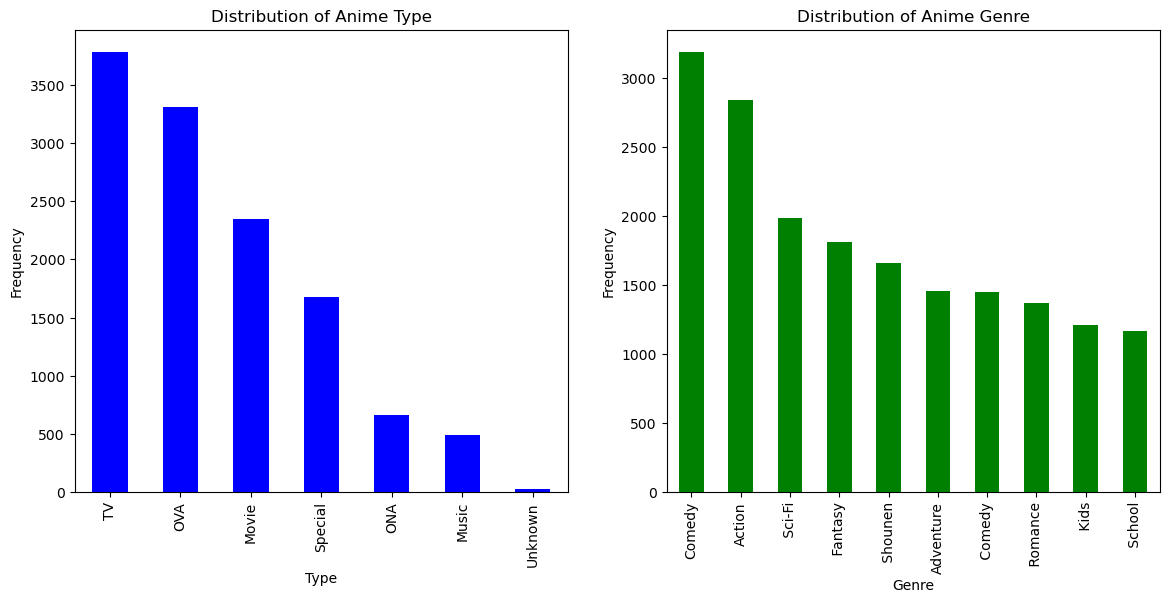

In [17]:
# Analyaze the categorical variables 
import matplotlib.pyplot as plt

type_counts = animes['type'].value_counts()
genre_counts = animes['genre'].str.split(',').explode().value_counts().head(10)

# plot 
fig, ax = plt.subplots(1,2,figsize=(14,6))

type_counts.plot(kind='bar', ax=ax[0], color='blue')
ax[0].set_title('Distribution of Anime Type')
ax[0].set_ylabel('Frequency')
ax[0].set_xlabel('Type')

genre_counts.plot(kind='bar', ax=ax[1], color='green')
ax[1].set_title('Distribution of Anime Genre')
ax[1].set_ylabel('Frequency')
ax[1].set_xlabel('Genre')

plt.show()